In [4]:
import rebound
import numpy as np
import random
import matplotlib.pyplot as plt
from tqdm import trange
import time
from scipy.optimize import curve_fit

# We add the BHs
M_1 = 3e9
q = 1
M_2 = q * M_1
M_total = M_1 + M_2

# Schwarzchild radius
c = 2.99792458e8 * 6.68459e-12 * (3600 * 24 * 365.2425)
G = 6.674e-11 * (6.68459e-12) ** 3 * (3600 * 24 * 365.2425) ** 2
M = M_1 * 1.989e30
R_sch = 2 * G * M / c**2

print(f'The Schwarzchild radius is {R_sch} ua')

#Sim parameters
N_years = 20000
N_frames = 600
t_array = np.linspace(0, N_years, N_frames)
Delta_time = N_years/N_frames
N_masses =100
M_spike = np.linspace(0.01, 1.6, N_masses)*M_1
avg_distance_tot = []

The Schwarzchild radius is 59.238711673042346 ua


Processing:   0%|          | 0/100 [00:00<?, ?it/s]

Generating 80 DM particles in the spike with mass 3.75e+05 Msun each...


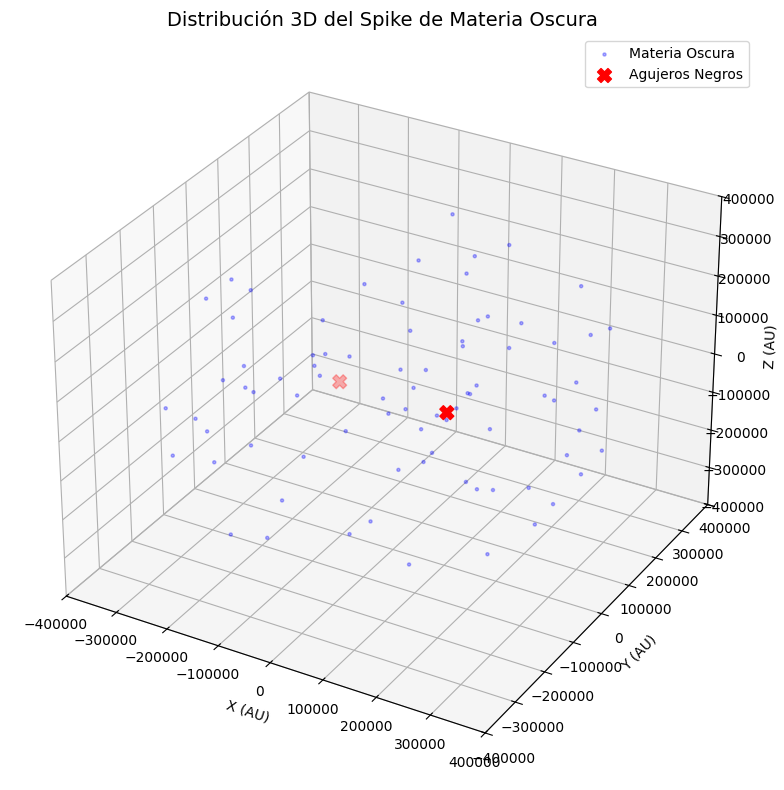

Processing:   1%|          | 1/100 [00:03<06:11,  3.75s/it]

Simulation for Mass M=30000000.0 completed
Generating 80 DM particles in the spike with mass 9.77e+05 Msun each...


Processing:   2%|▏         | 2/100 [00:08<07:00,  4.29s/it]

Simulation for Mass M=78181818.18181819 completed
Generating 80 DM particles in the spike with mass 1.58e+06 Msun each...


Processing:   3%|▎         | 3/100 [00:14<08:17,  5.13s/it]

...

Simulation for Mass M=319090909.09090906 completed
Generating 80 DM particles in the spike with mass 4.59e+06 Msun each...


Processing:   8%|▊         | 8/100 [01:02<13:49,  9.01s/it]

Simulation for Mass M=367272727.27272725 completed
Generating 80 DM particles in the spike with mass 5.19e+06 Msun each...


Processing:   8%|▊         | 8/100 [01:03<12:12,  7.97s/it]


KeyboardInterrupt: 

In [ ]:
for m in trange(len(M_spike), desc="Processing"):
    # Create an empty universe
    sim = rebound.Simulation()
    sim.units = ('yr', 'AU', 'Msun')
    sim.add(m=M_1)
    sim.add(m = M_2, a = 206265)

    # We define the BH
    black_hole_1 = sim.particles[0]
    black_hole_2 = sim.particles[1]

    # Define the DM spike
    N_particles = 80
    M_spike_total = M_spike[m]
    m_single_dm = M_spike_total / N_particles
    radius_spike = 400000
    bh_distance = []

    # Shifts the entire reference frame so the COM is at the origin
    sim.move_to_com()

    print(f"Generating {N_particles} DM particles in the spike with mass {m_single_dm:.2e} Msun each...")
    random.seed(0)

    # REJECTION SAMPLING METHOD FOR UNIFORM VOLUME DENSITY
    particles_added = 0
    while particles_added < N_particles:
        # 1. Pick a random 3D position in a Cartesian bounding box
        x = random.uniform(-radius_spike, radius_spike)
        y = random.uniform(-radius_spike, radius_spike)
        z = random.uniform(-radius_spike, radius_spike)
        
        # 2. Calculate the distance from the center (radius)
        r = np.sqrt(x**2 + y**2 + z**2)
        
        # 3. If it's outside our spherical shell, reject it and try again!
        # (Assuming you still want to keep the 1000 minimum distance from the BH)
        if r < 1000 or r > radius_spike:
            continue
        
        # 4. Calculate the required speed for a circular orbit
        # (Make sure M_total is defined somewhere above in your original code)
        v_circ = np.sqrt(sim.G * M_total / r)
        
        # 5. THE CROSS-PRODUCT TRICK
        pos_vec = np.array([x, y, z])
        # Pick any random direction
        random_vec = np.random.randn(3) 
        # The cross product guarantees a vector exactly 90 degrees to the position!
        perp_vec = np.cross(pos_vec, random_vec) 
        # Normalize it to a length of 1
        perp_vec = perp_vec / np.linalg.norm(perp_vec) 
        
        # 6. Scale the perpendicular vector to our orbital speed
        vel_vec = perp_vec * v_circ
        
        # Add the 3D particle to Rebound!
        sim.add(m=m_single_dm, x=x, y=y, z=z, vx=vel_vec[0], vy=vel_vec[1], vz=vel_vec[2])
        
        # Successfully added a valid particle
        particles_added += 1
    
    if m == 0:
        # Si estás en Jupyter Notebook, descomenta la siguiente línea para que el gráfico 3D sea interactivo:
        # %matplotlib widget 
        # Si usas Google Colab o prefieres un gráfico estático, usa:
        # %matplotlib inline

        # Extraer las coordenadas de la materia oscura (saltando los 2 primeros que son los Agujeros Negros)
        x_dm = [p.x for p in sim.particles[2:]]
        y_dm = [p.y for p in sim.particles[2:]]
        z_dm = [p.z for p in sim.particles[2:]]

        # Extraer las coordenadas de los Agujeros Negros para tener referencia
        x_bh = [sim.particles[0].x, sim.particles[1].x]
        y_bh = [sim.particles[0].y, sim.particles[1].y]
        z_bh = [sim.particles[0].z, sim.particles[1].z]

        # Configurar la figura 3D
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        # Dibujar las partículas de materia oscura (puntos pequeños y semitransparentes)
        ax.scatter(x_dm, y_dm, z_dm, s=5, c='blue', alpha=0.3, label='Materia Oscura')

        # Dibujar los Agujeros Negros (cruces rojas grandes)
        ax.scatter(x_bh, y_bh, z_bh, c='red', s=100, marker='X', label='Agujeros Negros')

        # Etiquetas y título
        ax.set_title('Distribución 3D del Spike de Materia Oscura', fontsize=14)
        ax.set_xlabel('X (AU)')
        ax.set_ylabel('Y (AU)')
        ax.set_zlabel('Z (AU)')

        # Ajustar los límites de los ejes para que la esfera no se vea ovalada
        max_range = np.array([sim.particles[0].x, sim.particles[0].y, sim.particles[0].z]).max() + 400000
        ax.set_xlim([-max_range, max_range])
        ax.set_ylim([-max_range, max_range])
        ax.set_zlim([-max_range, max_range])

        ax.legend()
        plt.tight_layout()
        plt.savefig(f'DM_distribution_N_CDM={N_masses}_uniformdistrib.pdf')
        plt.show() 
        
        
    # We give a collision radius to the BH
    sim.particles[0].r = R_sch
    sim.particles[1].r = R_sch

    # Turn the rebound collision detector
    sim.collision = "direct"

    # Tell rebound that if there is a collision then merge the particles
    sim.collision_resolve = "merge"
    
    sim.softening = R_sch # For softening the newtonian divergence in r--> 0

    for i in range(N_frames):
        next_time = sim.t + Delta_time
        sim.integrate(next_time)
        
        # Save the distances between blackhole
        bh_distance.append(black_hole_1 ** black_hole_2)
        
    # We convert to parsec
    bh_distance = np.array(bh_distance) / 206265

    avg_distance = [bh_distance[0]]
    for i in range(1, len(bh_distance)):
        a = min(i, 50)
        sum_dist = 0 # Changed 'sum' to 'sum_dist' to avoid shadowing built-in Python function
        for g in range(int(a)):
            sum_dist += bh_distance[i - g]
        
        avg_distance_new = sum_dist / a
        avg_distance.append(avg_distance_new)
        
    avg_distance_tot.append(avg_distance)
    print(f'Simulation for Mass M={M_spike[m]} completed')

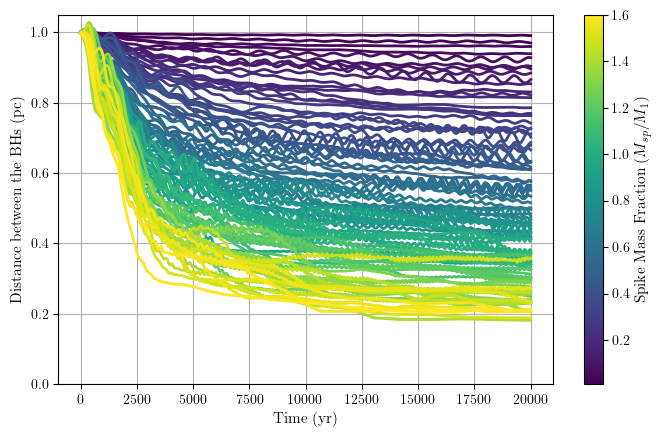

In [ ]:
# --- GLOBAL PLOT SETTINGS (Publication Quality) ---
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "font.size": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 12,
})

import matplotlib.cm as cm
import matplotlib.colors as mcolors

# --- GLOBAL PLOT SETTINGS --- 
fig1, ax1d = plt.subplots(figsize=(7, 4.5)) # Made slightly wider to fit the colorbar

# 1. Set up the Colormap 
cmap = cm.viridis 
norm = mcolors.Normalize(vmin=min(M_spike/M_1), vmax=max(M_spike/M_1))

# 2. Plot the lines using the colormap
for i in range(len(M_spike)):
    # Grab the specific color for this mass
    line_color = cmap(norm(M_spike[i]/M_1)) 
    
    # Plot without a label (since the colorbar will explain it)
    ax1d.plot(t_array, avg_distance_tot[i], color=line_color, linewidth=2)

# 3. Format the Axes
ax1d.set_xlabel('Time (yr)')
ax1d.set_ylabel('Distance between the BHs (pc)')
ax1d.set_ylim(0, 1.05)

# 4. Create and attach the Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # This is a matplotlib quirk required for colorbars
cbar = fig1.colorbar(sm, ax=ax1d)
cbar.set_label('Spike Mass Fraction ($M_{sp} / M_1$)', fontsize=11)

plt.grid()
plt.tight_layout()
fig1.savefig(f'Distance_vs_time_scanning_Mspike_N={N_particles}_Nscanning={N_masses}_softened2.pdf')
plt.show()

In [ ]:
np.savez(f'datos_distancia_vs_time_scanning_Mspike_N={N_particles}_Nscanning={N_masses}_softened.npz', avg_distance_tot = avg_distance_tot)